# Tutorial 1: Embryonic Mouse Brain

This tutorial demonstrates **mmVelo** applied to 10x Multiome data from the embryonic mouse brain (E18). We train a deep generative model to jointly infer cell state dynamics, spliced RNA velocity, and chromatin velocity.

**Reference**: 10x Genomics E18 mouse brain dataset.

**Output**: `experiments/mouse_brain/`

## 1. Setup

In [ ]:
import os, sys, json
import numpy as np
import pandas as pd
import scipy.sparse
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pytorch_lightning as pl
import scanpy as sc
import scvelo as scv
import anndata as ad

sys.path.insert(0, "src/")
%matplotlib inline

SEED = 43
np.random.seed(SEED); torch.manual_seed(SEED); pl.seed_everything(SEED, workers=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
RUN_PATH = "experiments/mouse_brain"
os.makedirs(RUN_PATH, exist_ok=True)
print(f"Device: {device}  |  Output: {RUN_PATH}")


Global seed set to 43


Device: cuda  |  Output: experiments/mouse_brain


## 2. Hyperparameters

In [13]:
params = dict(
    zdim=10, r_h1dim=128, r_h2dim=64, a_h1dim=128, a_h2dim=64, d_h_dim=64,
    lr=1e-4, lr_dyn=1e-4, num_epochs=1000,
    patience=30, warmup=30, warmup_dyn=10,
    batch_size=128, n_neighbors=100,
    su_corr=-1, su_ratio=50, min_counts_su=20,
)


## 3. Data Loading

In [14]:
from mmvelo_tutorial.dataset_mouse_brain import TutorialBrainDataModule

dm = TutorialBrainDataModule("data/mouse_brain", batch_size=params["batch_size"], seed=SEED)


Loading RNA data...
Loading ATAC data...
RNA dim  : 3072
ATAC dim : 25071
# cells  : 3735
train: 2989  val: 373  test: 373


## 4. Stage 1: Cell State Inference

`DREG_PRE` learns a joint latent representation from spliced, unspliced, and ATAC data.
Checkpoint is reused automatically if it already exists.

In [15]:
from mmvelo_tutorial.train_mouse_brain import run_stage1

dm = run_stage1(dm, RUN_PATH, params, device=device)


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Running Stage 1 prediction on all cells...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

Latent shape: (3735, 10)


## 5. Reconstruction Quality

Per-gene Pearson correlation between observed and reconstructed counts.

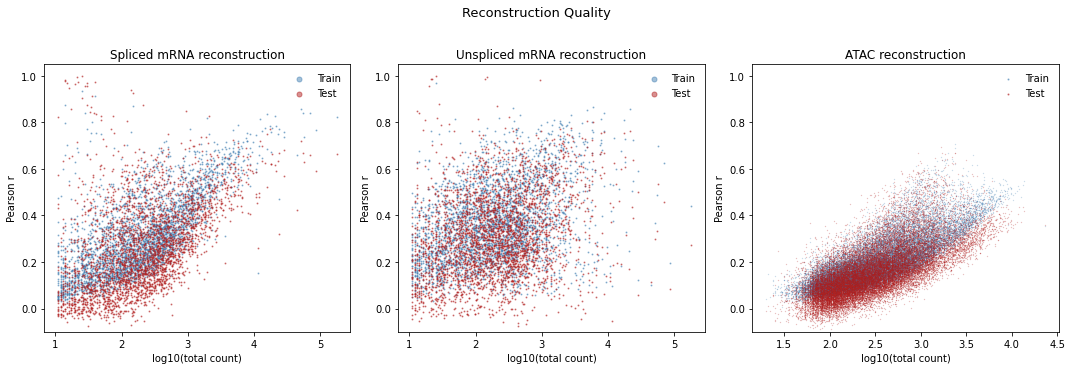

In [16]:
def _dense(x):
    return x.toarray().astype(np.float32) if scipy.sparse.issparse(x) else np.asarray(x, np.float32)

test_idx = dm.idx["test"]
train_idx = dm.idx["train"]

obs_s = _dense(dm.adata_r.layers["spliced"])
obs_u = _dense(dm.adata_r.layers["unspliced"])
obs_a = _dense(dm.adata_a.X)
rec_s = _dense(dm.adata_r.layers["rec_s"])
rec_u = _dense(dm.adata_r.layers["rec_u"])
rec_a = _dense(dm.adata_a.layers["rec_a"])

log_cs = np.log10(obs_s.sum(0) + 1)
log_ca = np.log10(obs_a.sum(0) + 1)

def pearson_cols(x, y):
    return np.array([scipy.stats.pearsonr(x[:, i], y[:, i])[0]
                     if x[:, i].std() > 1e-8 else np.nan for i in range(x.shape[1])])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, lc, obs, rec, title in zip(axes, [log_cs, log_cs, log_ca],
        [obs_s, obs_u, obs_a], [rec_s, rec_u, rec_a],
        ["Spliced mRNA", "Unspliced mRNA", "ATAC"]):
    s = 1.0 if "ATAC" not in title else 0.05
    ax.scatter(lc, pearson_cols(obs[train_idx], rec[train_idx]), c="steelblue",  s=s, alpha=0.5, label="Train")
    ax.scatter(lc, pearson_cols(obs[test_idx],  rec[test_idx]),  c="firebrick",  s=s, alpha=0.5, label="Test")
    ax.set(xlabel="log10(total count)", ylabel="Pearson r", title=f"{title} reconstruction", ylim=(-0.1, 1.05))
    ax.legend(markerscale=5, frameon=False)
plt.suptitle("Reconstruction Quality", fontsize=13, y=1.02); plt.tight_layout(); plt.show()


## 6. Stage 2: Smoothed Profile Reconstruction

In [17]:
from mmvelo_tutorial.train_mouse_brain import build_smooth_dm, run_stage2

dm_s = build_smooth_dm(dm, params)
dm_s = run_stage2(dm, dm_s, RUN_PATH, params, device=device)


RNA dim : 3072 ATAC dim : 25071
Normalized count data: X, spliced, unspliced.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
DynDataModule_Smooth ready.
Running Stage 2 prediction on all cells...


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

s_raw shape: (3735, 3072)


## 7. Stage 3: Cell State Dynamics Inference

`DREG_DYN` learns latent dynamics and maps them to spliced/unspliced/ATAC velocities.

In [18]:
from mmvelo_tutorial.train_mouse_brain import run_stage3

dm_s = run_stage3(dm, dm_s, RUN_PATH, params, device=device)


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


# genes excluded for estimation 419
# genes for estimation 2653.0
Genes for dynamics: 2653 / 3072
Running Stage 3 prediction on all cells...


Predicting: 0it [00:00, ?it/s]

dsdt shape : (3735, 3072)
dadt shape : (3735, 25071)


## 8. Save Results

In [19]:
from mmvelo_tutorial.train_mouse_brain import save_results

save_results(dm_s, RUN_PATH)


Results saved to experiments/mouse_brain/


## 9. Load Results and Compute UMAP

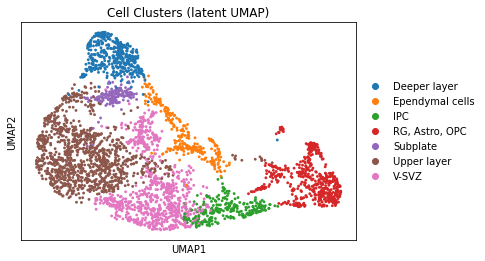

In [20]:
adata_r = sc.read_loom(f"{RUN_PATH}/adata_rna.loom", obs_names="obs_names", var_names="var_names")
adata_a = sc.read_loom(f"{RUN_PATH}/adata_atac.loom", obs_names="obs_names", var_names="var_names")

norm_mat_s = np.loadtxt(f"{RUN_PATH}/norm_mat_s.txt")
norm_mat_u = np.loadtxt(f"{RUN_PATH}/norm_mat_u.txt")
norm_mat_a = np.loadtxt(f"{RUN_PATH}/norm_mat_a.txt")

with open("data/mouse_brain/cell_clusters.json") as f:
    cell_clusters = json.load(f)
adata_r.obs["clusters"] = adata_r.obs_names.map(cell_clusters).values
adata_a.obs["clusters"] = adata_r.obs["clusters"].values

import umap as umap_module
z_mat = adata_r.obsm["latent"]
X_umap = umap_module.UMAP(n_neighbors=30, min_dist=0.2, random_state=SEED).fit_transform(z_mat)
adata_r.obsm["X_umap"] = X_umap
adata_a.obsm["X_umap"] = X_umap

sc.pp.neighbors(adata_r, n_neighbors=params["n_neighbors"], use_rep="latent")
adata_a.uns["neighbors"]      = adata_r.uns["neighbors"]
adata_a.obsp["distances"]     = adata_r.obsp["distances"]
adata_a.obsp["connectivities"] = adata_r.obsp["connectivities"]

sc.pl.umap(adata_r, color="clusters", title="Cell Clusters (latent UMAP)")

# Reconstruct split for VCS
from mmvelo_tutorial.dataset_mouse_brain import split_data
idx = split_data(adata_r, seed=SEED)
train_idx, test_idx = idx["train"], idx["test"]


## 10. Velocity Consistency Score (VCS)

VCS measures how well velocity signs agree with expression changes along pseudotime.

VCS median — spliced: 1.0456  unspliced: 1.1208  ATAC: 0.0678


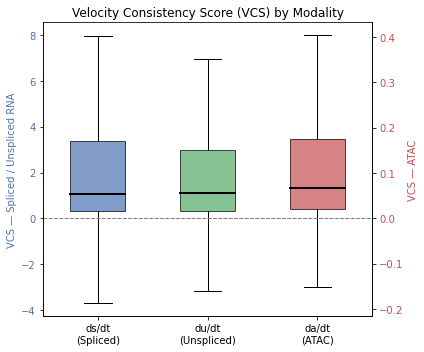

In [ ]:
pseudotime = pd.read_csv("data/mouse_brain/pseudotime.tsv", sep="\t", header=None)[0].values

def compute_vcs(x_mat, v_mat, pseudotime, n_bins=10):
    order = np.argsort(pseudotime)
    bins  = np.array_split(order, n_bins)
    bin_means = np.stack([x_mat[idx].mean(0) for idx in bins])
    delta = bin_means[1:] - bin_means[:-1]
    vcs = np.zeros(x_mat.shape[1], np.float32)
    for t, idx in enumerate(bins[:-1]):
        vcs += delta[t] * np.sign(v_mat[idx]).mean(0)
    return vcs

Ms = _dense(adata_r.layers["Ms"]); Mu = _dense(adata_r.layers["Mu"])
Ma = _dense(adata_a.layers["Ma"])
dsdt_v = _dense(adata_r.layers["dsdt"]); dudt_v = _dense(adata_r.layers["dudt"])
dadt_v = _dense(adata_a.layers["dadt"])

vcs_s = compute_vcs(Ms, dsdt_v, pseudotime)
vcs_u = compute_vcs(Mu, dudt_v, pseudotime)
vcs_a = compute_vcs(Ma, dadt_v, pseudotime)
print(f"VCS median — spliced: {np.nanmedian(vcs_s):.4f}  unspliced: {np.nanmedian(vcs_u):.4f}  ATAC: {np.nanmedian(vcs_a):.4f}")

# ── Dual y-axis boxplot: RNA on left, ATAC on right ──────────────────────────
fig, ax1 = plt.subplots(figsize=(6, 5))
ax2 = ax1.twinx()

rna_data  = [vcs_s[np.isfinite(vcs_s)], vcs_u[np.isfinite(vcs_u)]]
atac_data = [vcs_a[np.isfinite(vcs_a)]]

bp1 = ax1.boxplot(rna_data, positions=[1, 2], widths=0.5,
    patch_artist=True, notch=False, showfliers=False,
    medianprops=dict(linewidth=2, color="black"))
bp2 = ax2.boxplot(atac_data, positions=[3], widths=0.5,
    patch_artist=True, notch=False, showfliers=False,
    medianprops=dict(linewidth=2, color="black"))

colors = ["#4C72B0", "#55A868", "#C44E52"]
for patch, c in zip(list(bp1["boxes"]) + list(bp2["boxes"]), colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)

# ── Align y=0 at the same vertical position on both axes ─────────────────────
def _align_zero(ax_left, ax_right):
    lo1, hi1 = ax_left.get_ylim()
    lo2, hi2 = ax_right.get_ylim()
    # r = |negative extent| / positive extent  (zero is at r/(1+r) from bottom)
    r1 = abs(lo1) / hi1 if hi1 > 0 else 0.0
    r2 = abs(lo2) / hi2 if hi2 > 0 else 0.0
    r  = max(r1, r2)
    # Expand negative side to match r; never clip positive data
    ax_left.set_ylim(-r * hi1, hi1)
    ax_right.set_ylim(-r * hi2, hi2)

_align_zero(ax1, ax2)

ax1.axhline(0, color="grey", lw=1, ls="--")
ax2.axhline(0, color="grey", lw=1, ls="--")

ax1.set_xlim(0.5, 3.5)
ax2.set_xlim(0.5, 3.5)
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(["ds/dt\n(Spliced)", "du/dt\n(Unspliced)", "da/dt\n(ATAC)"])

ax1.set_ylabel("VCS — Spliced / Unspliced RNA", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax2.set_ylabel("VCS — ATAC", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")

ax1.set_title("Velocity Consistency Score (VCS) by Modality")
sns.despine(ax=ax1, right=False)
plt.tight_layout()
plt.show()


## 11. Streamline Plots

computing velocity graph (using 4/24 cores)


  0%|          | 0/3735 [00:00<?, ?cells/s]

    finished (0:00:04) --> added 
    'dynamics_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'dynamics_umap', embedded velocity vectors (adata.obsm)


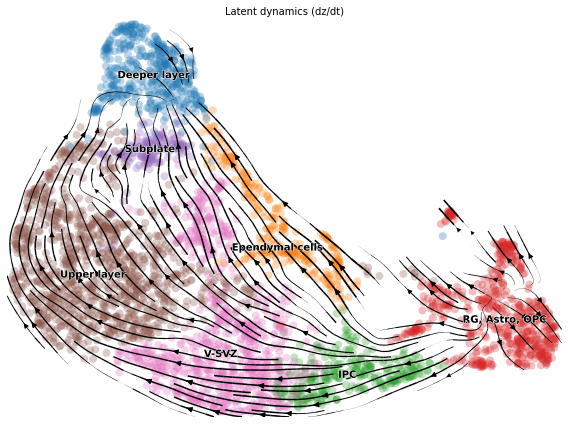

computing velocity graph (using 4/24 cores)


  0%|          | 0/3735 [00:00<?, ?cells/s]

    finished (0:00:40) --> added 
    'dsdt_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'dsdt_umap', embedded velocity vectors (adata.obsm)


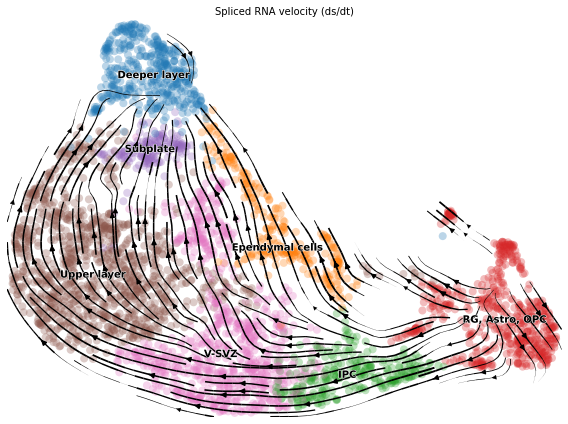

computing velocity graph (using 4/24 cores)


  0%|          | 0/3735 [00:00<?, ?cells/s]

    finished (0:04:02) --> added 
    'dadt_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'dadt_umap', embedded velocity vectors (adata.obsm)


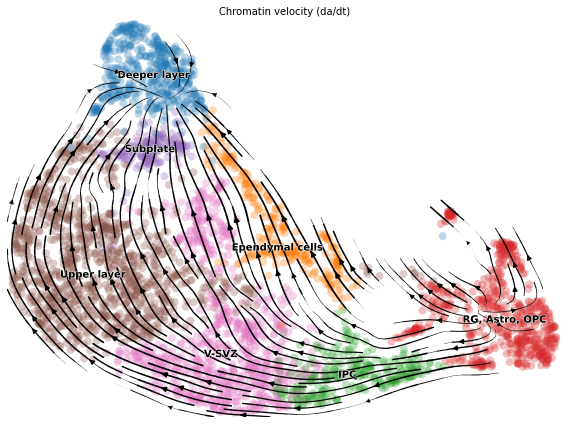

In [22]:
from mmvelo_multi.streamlineplot import velocity_graph

# Latent dynamics AnnData (built from obsm arrays — always float)
adata_z = ad.AnnData(X=adata_r.obsm["latent"])
adata_z.obs_names = adata_r.obs_names
adata_z.obsm["latent"]  = adata_r.obsm["latent"]
adata_z.layers["latent"] = adata_r.obsm["latent"]
adata_z.layers["dynamics"] = adata_r.obsm["dynamics"]
adata_z.obsm["X_umap"]  = adata_r.obsm["X_umap"]
adata_z.obsp["distances"] = adata_r.obsp["distances"]
adata_z.obsp["connectivities"] = adata_r.obsp["connectivities"]
adata_z.uns["neighbors"] = adata_r.uns["neighbors"]
adata_z.obs["clusters"]  = adata_r.obs["clusters"].values

for adata, vkey, xkey, title in [
    (adata_z, "dynamics", "latent",  "Latent dynamics (dz/dt)"),
    (adata_r, "dsdt",     "s_raw",   "Spliced RNA velocity (ds/dt)"),
    (adata_a, "dadt",     "a_raw",   "Chromatin velocity (da/dt)"),
]:
    # Layers loaded from loom may not be float; scvelo's np.isnan() requires float.
    for key in [vkey, xkey]:
        if key in adata.layers:
            v = adata.layers[key]
            if hasattr(v, "toarray"):
                adata.layers[key] = v.toarray().astype(np.float32)
            elif not np.issubdtype(v.dtype, np.floating):
                adata.layers[key] = v.astype(np.float32)

    velocity_graph(adata, vkey=vkey, xkey=xkey, n_jobs=4)
    scv.tl.velocity_embedding(adata, basis="umap", vkey=vkey)
    fig, ax = plt.subplots(figsize=(8, 6))
    scv.pl.velocity_embedding_stream(adata, vkey=vkey, color="clusters",
        title=title, ax=ax, show=False, min_mass=0)
    plt.tight_layout(); plt.show()


## 12. Velocity Uncertainty (On/Off-manifold Decomposition)

[Phase 1] Collecting z_hat, x_RNA, x_ATAC for all cells...
          N=3735, rna_dim=3072, atac_dim=25071
[Phase 2] Building modality-specific embeddings and kNN graphs (RNA: PCA-50, ATAC: SVD-50, k=50)...
          embed_rna=(3735, 50), embed_atac=(3735, 50)
[Phase 3] Computing modality-specific on/off-manifold decomposition (n_samples=100, manifold_dim_rna=10, manifold_dim_atac=10)...


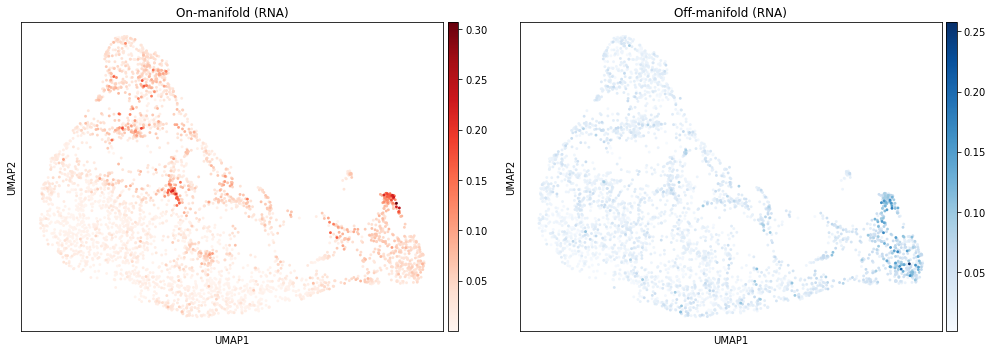

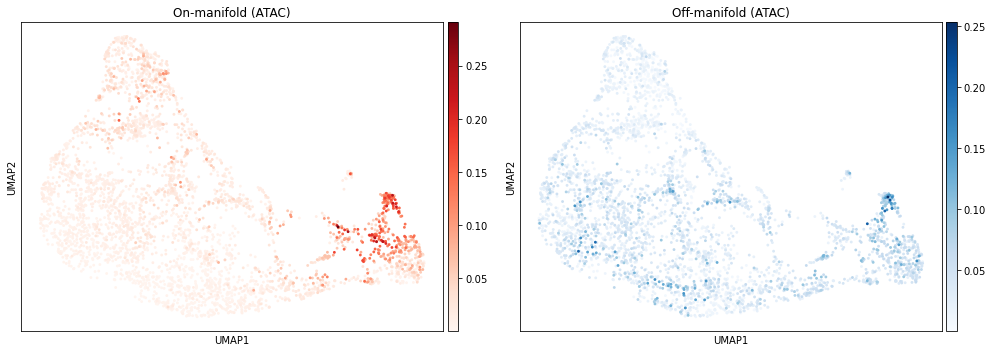

In [23]:
from mmvelo_multi.velocity_off_manifold_mod import compute_off_manifold_uncertainty_mod
from mmvelo_multi.models import DREG_DYN, EarlyStoppingWithWarmup

filter_idx = torch.tensor(dm_s.adata_r.var["estimated_genes"].values.astype(np.float32))

class _DenseDS(torch.utils.data.Dataset):
    def __init__(self, s, u, a, ms, mu, ma):
        self.data = [s, u, a, ms, mu, ma]
    def __len__(self): return self.data[0].shape[0]
    def __getitem__(self, i): return tuple(torch.tensor(x[i]) for x in self.data)

s_c = _dense(adata_r.layers.get("spliced_count", adata_r.layers["spliced"]))
u_c = _dense(adata_r.layers.get("unspliced_count", adata_r.layers["unspliced"]))
a_c = _dense(adata_a.layers.get("atac_count", adata_a.X))
dl = torch.utils.data.DataLoader(_DenseDS(s_c, u_c, a_c, _dense(adata_r.layers["Ms"]),
    _dense(adata_r.layers["Mu"]), _dense(adata_a.layers["Ma"])),
    batch_size=params["batch_size"], shuffle=False, num_workers=2, pin_memory=True)

model_unc = DREG_DYN.load_from_checkpoint(
    f"{RUN_PATH}/checkpoint.ckpt",
    rna_dim=adata_r.shape[1], atac_dim=adata_a.shape[1],
    r_h1_dim=params["r_h1dim"], r_h2_dim=params["r_h2dim"],
    a_h1_dim=params["a_h1dim"], a_h2_dim=params["a_h2dim"],
    z_dim=params["zdim"], d_h_dim=params["d_h_dim"],
    l_prior_r=dm.l_prior_r, l_prior_a=dm.l_prior_a,
    lr=params["lr_dyn"], z_learnable=True, d_coeff=1e-2, warmup=params["warmup_dyn"],
    filter_idx=filter_idx.to(device), strict=False,
)
model_unc.register_buffer("norm_mat_s", torch.tensor(norm_mat_s, dtype=torch.float32))
model_unc.register_buffer("norm_mat_u", torch.tensor(norm_mat_u, dtype=torch.float32))
model_unc.register_buffer("norm_mat_a", torch.tensor(norm_mat_a, dtype=torch.float32))
model_unc.register_buffer("retain_gene_idx", torch.ones(adata_r.shape[1]))
model_unc.register_buffer("filter_idx", filter_idx)
model_unc.eval()

unc = compute_off_manifold_uncertainty_mod(model_unc, dl,
    n_samples=100, n_neighbors=50, n_pca_rna=50, n_lsi_atac=50,
    manifold_dim_rna=10, manifold_dim_atac=10, device=device)

for key in ["u_dyn_rna", "u_dyn_par_rna", "u_dyn_perp_rna"]:
    adata_r.obs[key] = unc[key]
for key in ["u_dyn_atac", "u_dyn_par_atac", "u_dyn_perp_atac"]:
    adata_a.obs[key] = unc[key]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata_r, color="u_dyn_par_rna",  ax=axes[0], title="On-manifold (RNA)",  show=False, color_map="Reds")
sc.pl.umap(adata_r, color="u_dyn_perp_rna", ax=axes[1], title="Off-manifold (RNA)", show=False, color_map="Blues")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata_a, color="u_dyn_par_atac",  ax=axes[0], title="On-manifold (ATAC)",  show=False, color_map="Reds")
sc.pl.umap(adata_a, color="u_dyn_perp_atac", ax=axes[1], title="Off-manifold (ATAC)", show=False, color_map="Blues")
plt.tight_layout(); plt.show()
